In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


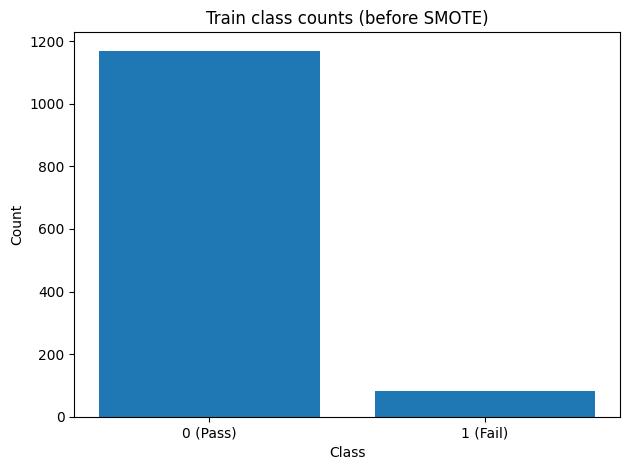

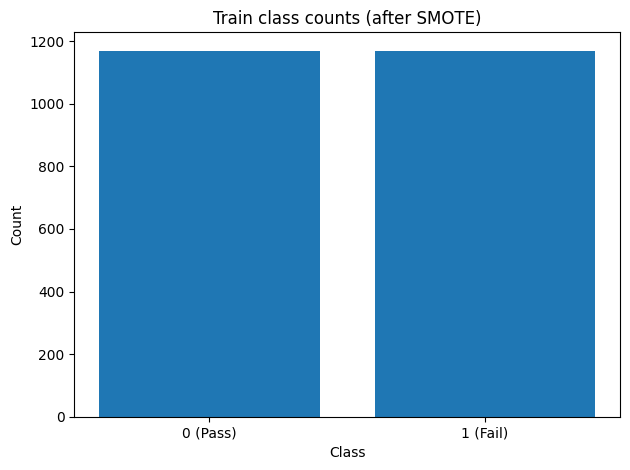

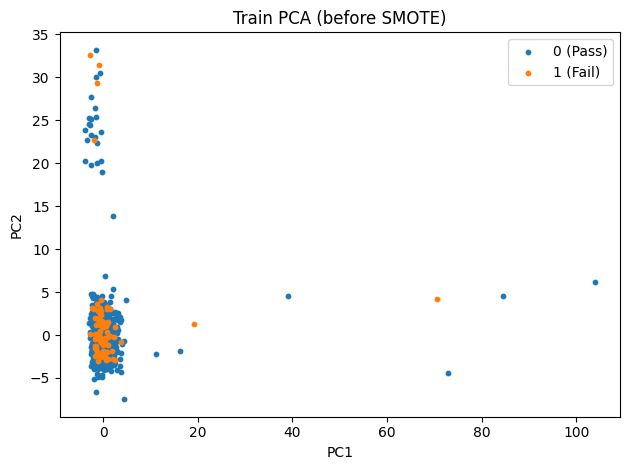

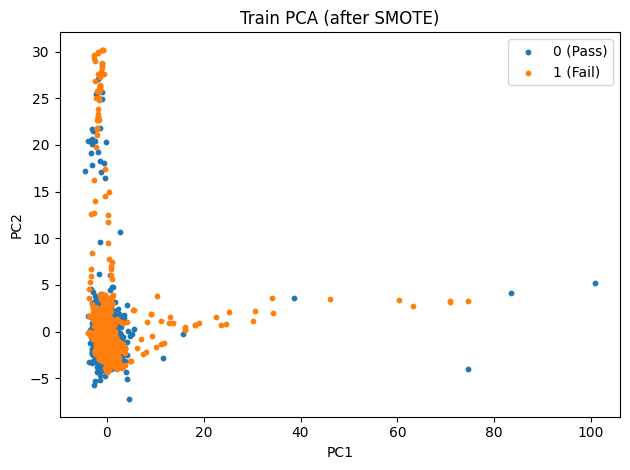

In [28]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append(m)
        print(f"[{model_name}] fold={fold} acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
              f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    avg = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg

imp = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

# ── 0) 只在訓練集 fit 補值器 ──
Xtr_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# ── 1) 類別數量：SMOTE 前/後 ──
cnt_before = y_train.value_counts().sort_index()
Xtr_sm, ytr_sm = smote.fit_resample(Xtr_imp, y_train)
cnt_after  = pd.Series(ytr_sm).value_counts().sort_index()

# (A) 訓練集類別數量（前）
plt.figure()
plt.bar(['0 (Pass)','1 (Fail)'], cnt_before.values)
plt.title('Train class counts (before SMOTE)')
plt.xlabel('Class'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

# (B) 訓練集類別數量（後）
plt.figure()
plt.bar(['0 (Pass)','1 (Fail)'], cnt_after.values)
plt.title('Train class counts (after SMOTE)')
plt.xlabel('Class'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

# 前：標準化→PCA
sc_before = StandardScaler().fit(Xtr_imp)
Z_before = PCA(n_components=2, random_state=42).fit_transform(sc_before.transform(Xtr_imp))

# 後：標準化→PCA（重新 fit 在 SMOTE 後資料）
sc_after = StandardScaler().fit(Xtr_sm)
Z_after  = PCA(n_components=2, random_state=42).fit_transform(sc_after.transform(Xtr_sm))

# (C) PCA 散佈：SMOTE 前
plt.figure()
m0 = (y_train.values==0); m1 = ~m0
plt.scatter(Z_before[m0,0], Z_before[m0,1], s=10, label='0 (Pass)')
plt.scatter(Z_before[m1,0], Z_before[m1,1], s=10, label='1 (Fail)')
plt.title('Train PCA (before SMOTE)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()
plt.tight_layout(); plt.show()

# (D) PCA 散佈：SMOTE 後
plt.figure()
m0 = (np.array(ytr_sm)==0); m1 = ~m0
plt.scatter(Z_after[m0,0], Z_after[m0,1], s=10, label='0 (Pass)')
plt.scatter(Z_after[m1,0], Z_after[m1,1], s=10, label='1 (Fail)')
plt.title('Train PCA (after SMOTE)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()
plt.tight_layout(); plt.show()


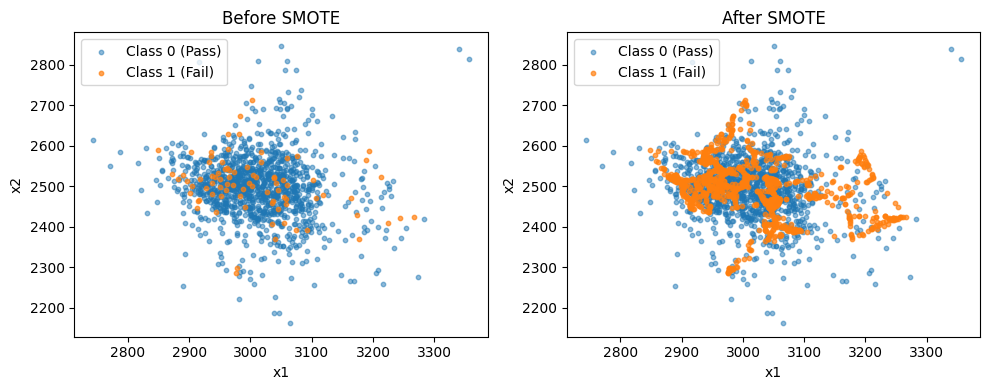

In [32]:
# ── 1) 只用訓練集 fit 補值器 ──
Xtr_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# ── 2) 取前兩個特徵 x1, x2 ──
cols = ['x1', 'x2']   # 直接取前兩欄
X2 = Xtr_imp[cols].copy()

# ── 3) SMOTE 後資料 ──
X_sm, y_sm = smote.fit_resample(X2, y_train)

# ── 4) 繪圖：SMOTE 前後散點比較 ──
plt.figure(figsize=(10, 4))

# (A) Before SMOTE
plt.subplot(1, 2, 1)
plt.scatter(X2[y_train==0].iloc[:,0], X2[y_train==0].iloc[:,1], s=10, alpha=0.5, label='Class 0 (Pass)')
plt.scatter(X2[y_train==1].iloc[:,0], X2[y_train==1].iloc[:,1], s=10, alpha=0.7, label='Class 1 (Fail)')
plt.xlabel(cols[0]); plt.ylabel(cols[1])
plt.title('Before SMOTE')
plt.legend()

# (B) After SMOTE
plt.subplot(1, 2, 2)
plt.scatter(X_sm[y_sm==0].iloc[:,0], X_sm[y_sm==0].iloc[:,1], s=10, alpha=0.5, label='Class 0 (Pass)')
plt.scatter(X_sm[y_sm==1].iloc[:,0], X_sm[y_sm==1].iloc[:,1], s=10, alpha=0.7, label='Class 1 (Fail)')
plt.xlabel(cols[0]); plt.ylabel(cols[1])
plt.title('After SMOTE')
plt.legend()

plt.tight_layout()
plt.show()


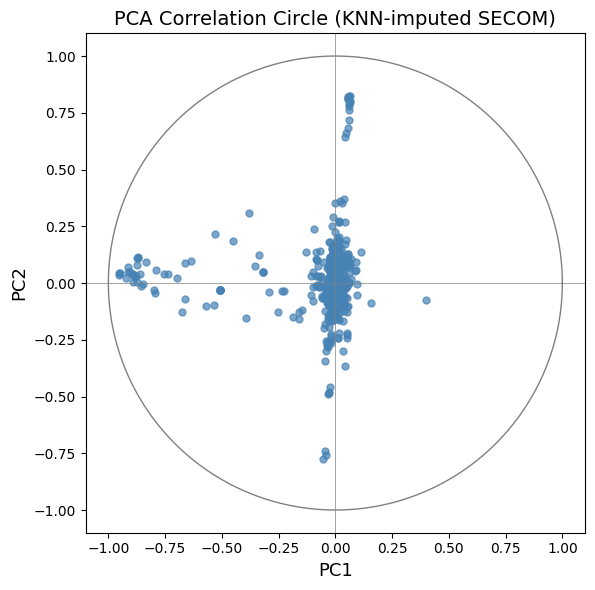

In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = imputer.fit_transform(X)

# 3) 標準化
X_std = StandardScaler().fit_transform(X_imp)

# 4) PCA（手動協方差分解）
cov_mat = np.cov(X_std, rowvar=False)
eigen_val, eigen_vec = np.linalg.eigh(cov_mat)
idx_sorted = np.argsort(eigen_val)[::-1]
lamda_ = eigen_val[idx_sorted][:2]
vector_ = eigen_vec[:, idx_sorted][:, :2]

# 5) correlation circle
corr = vector_ * np.sqrt(lamda_)

theta = np.linspace(0, 2*np.pi, 361)
ucircle = np.c_[np.cos(theta), np.sin(theta)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ucircle[:,0], ucircle[:,1], color='grey', lw=1)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

# 只畫點，不加虛線和標籤
ax.scatter(corr[:,0], corr[:,1], color='steelblue', s=25, alpha=0.7)

ax.set_xlabel('PC1', fontsize=13)
ax.set_ylabel('PC2', fontsize=13)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()  

### 所有機器學習模型10折的結果, 不作特徵選擇, 中位數補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9338 | 0.0017 |    0.0236   |    0.9983   | 0.0687 |
| **XGBoost**        | 0.9298 | 0.0111 |    0.0958   |    0.9889   | 0.2147 |
| **DecisionTree**   | 0.8260 | 0.1282 |    0.1792   |    0.8718   | 0.3470 |
| **LinearReg**      | 0.8013 | 0.1667 |    0.3500   |    0.8333   | 0.5210 |
| **Lasso-Logistic** | 0.8452 | 0.1154 |    0.2903   |    0.8846   | 0.4417 |



[RandomForest] MEAN acc=0.9338 FAR=0.0017 sens=0.0236 spec=0.9983 GM=0.0687
[XGBoost] MEAN acc=0.9298 FAR=0.0111 sens=0.0958 spec=0.9889 GM=0.2147
[DecisionTree] MEAN acc=0.8260 FAR=0.1282 sens=0.1792 spec=0.8718 GM=0.3470
[LinearReg] MEAN acc=0.8013 FAR=0.1667 sens=0.3500 spec=0.8333 GM=0.5210
[Lasso-Logistic] MEAN acc=0.8452 FAR=0.1154 sens=0.2903 spec=0.8846 GM=0.4417


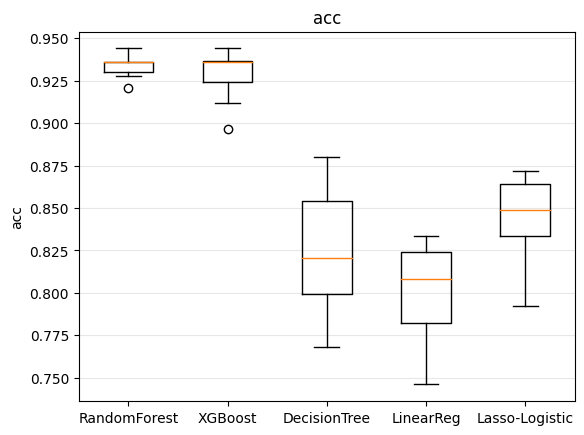

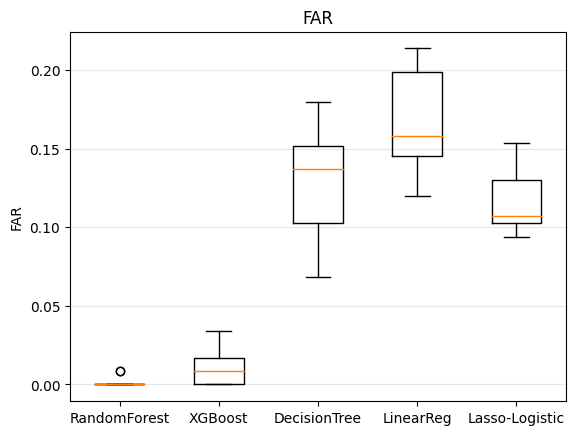

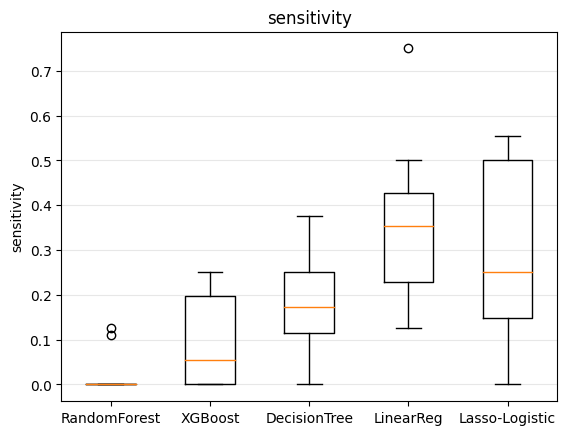

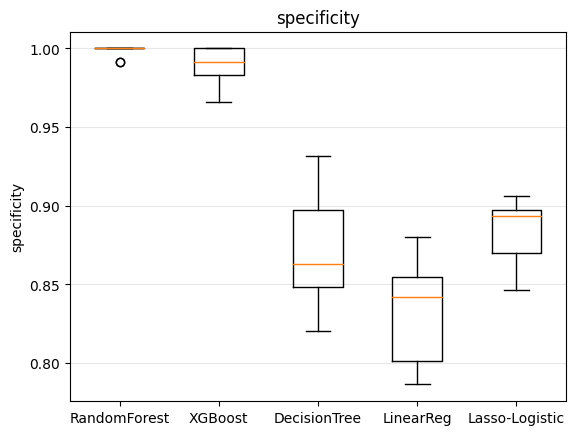

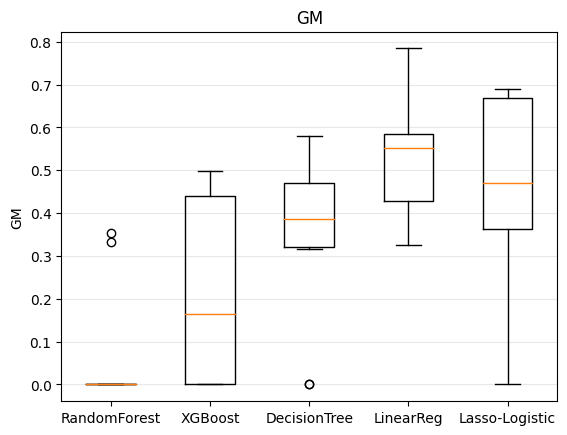

In [60]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

xgb_pipe = ImbPipeline(steps=[('impute', imp),
                           ('smote', smote),
                           ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

lasso_logit_pipe = ImbPipeline(steps=[('impute', imp),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

rfc_pipe = ImbPipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

dt_pipe = ImbPipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(random_state=42))])

linr_pipe = ImbPipeline(steps=[('impute', imp),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)


cv_df = pd.concat(fold_dfs, ignore_index=True)

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()


---
### 所有機器學習模型的10折結果, 不作特徵選擇, KNN補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9314 | 0.0034 |    0.0111   |    0.9966   | 0.0333 |
| **XGBoost**        | 0.9290 | 0.0120 |    0.0958   |    0.9880   | 0.2141 |
| **DecisionTree**   | 0.8476 | 0.1120 |    0.2778   |    0.8880   | 0.4863 |
| **LinearReg**      | 0.7958 | 0.1744 |    0.3736   |    0.8256   | 0.5383 |
| **Lasso-Logistic** | 0.8476 | 0.1154 |    0.3278   |    0.8846   | 0.4905 |


[RandomForest] MEAN acc=0.9314 FAR=0.0034 sens=0.0111 spec=0.9966 GM=0.0333
[XGBoost] MEAN acc=0.9290 FAR=0.0120 sens=0.0958 spec=0.9880 GM=0.2141
[DecisionTree] MEAN acc=0.8476 FAR=0.1120 sens=0.2778 spec=0.8880 GM=0.4863
[LinearReg] MEAN acc=0.7958 FAR=0.1744 sens=0.3736 spec=0.8256 GM=0.5383
[Lasso-Logistic] MEAN acc=0.8476 FAR=0.1154 sens=0.3278 spec=0.8846 GM=0.4905


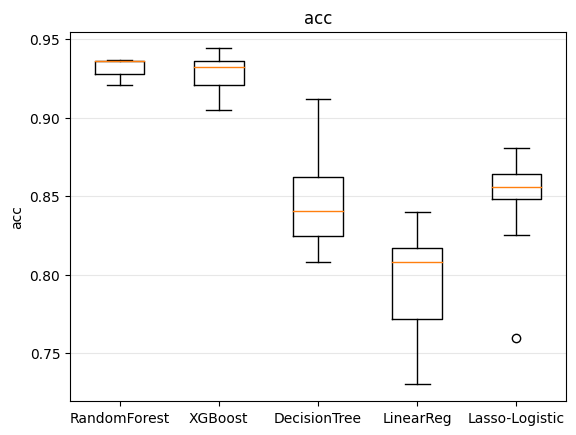

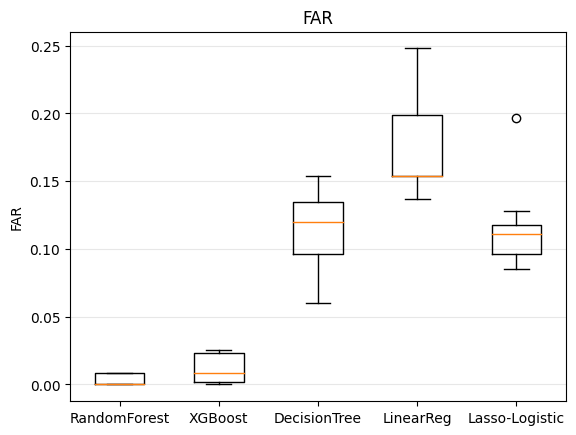

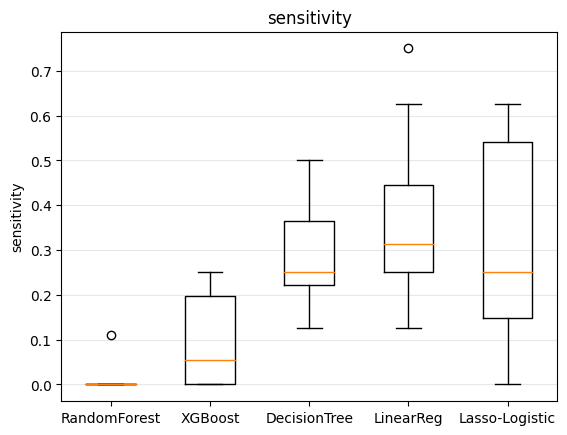

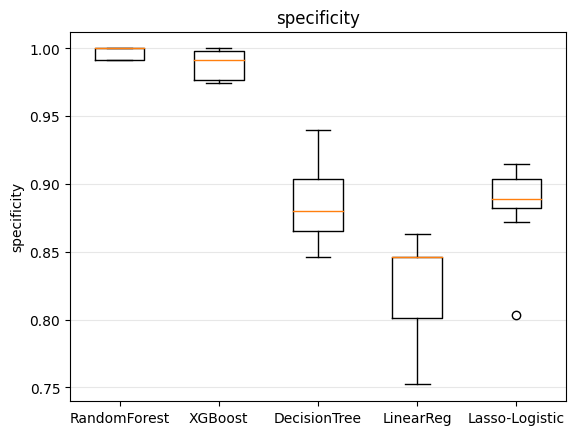

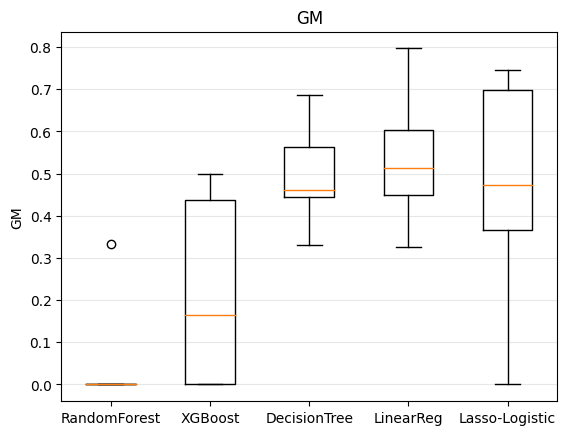

In [59]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

xgb_pipe = ImbPipeline(steps=[('impute', knn),
                           ('smote', smote),
                           ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

lasso_logit_pipe = ImbPipeline(steps=[('impute', knn),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

rfc_pipe = ImbPipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

dt_pipe = ImbPipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(random_state=42))])

linr_pipe = ImbPipeline(steps=[('impute', knn),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

---
### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, 中位數補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9306 | 0.0043 |    0.0111   |    0.9957   | 0.0333 |
| **XGBoost**        | 0.9242 | 0.0145 |    0.0583   |    0.9855   | 0.1296 |
| **DecisionTree**   | 0.8476 | 0.1103 |    0.2528   |    0.8897   | 0.4343 |
| **LinearReg**      | 0.8061 | 0.1607 |    0.3389   |    0.8393   | 0.5092 |
| **Lasso-Logistic** | 0.8484 | 0.1145 |    0.3250   |    0.8855   | 0.4652 |


[RandomForest] MEAN acc=0.9306 FAR=0.0043 sens=0.0111 spec=0.9957 GM=0.0333
[XGBoost] MEAN acc=0.9242 FAR=0.0145 sens=0.0583 spec=0.9855 GM=0.1296
[DecisionTree] MEAN acc=0.8476 FAR=0.1103 sens=0.2528 spec=0.8897 GM=0.4343
[LinearReg] MEAN acc=0.8061 FAR=0.1607 sens=0.3389 spec=0.8393 GM=0.5092
[Lasso-Logistic] MEAN acc=0.8484 FAR=0.1145 sens=0.3250 spec=0.8855 GM=0.4652


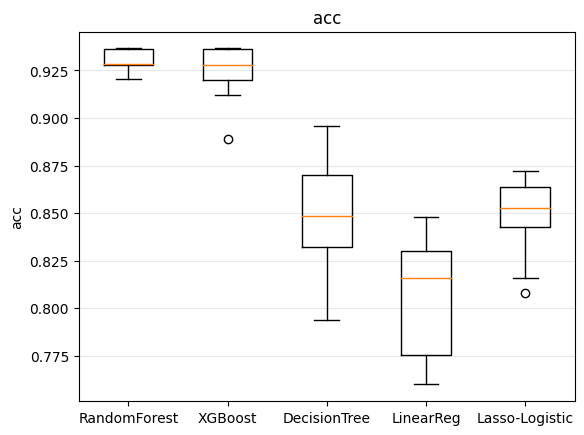

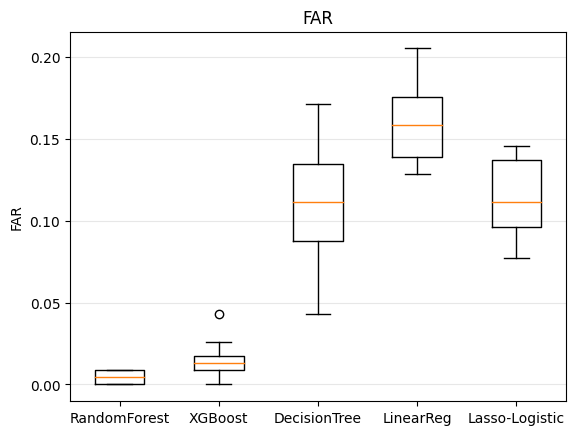

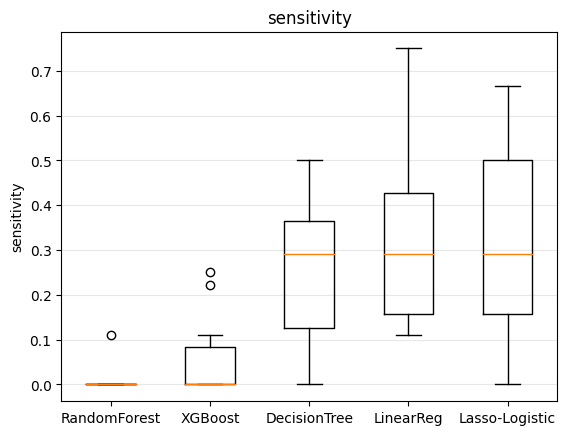

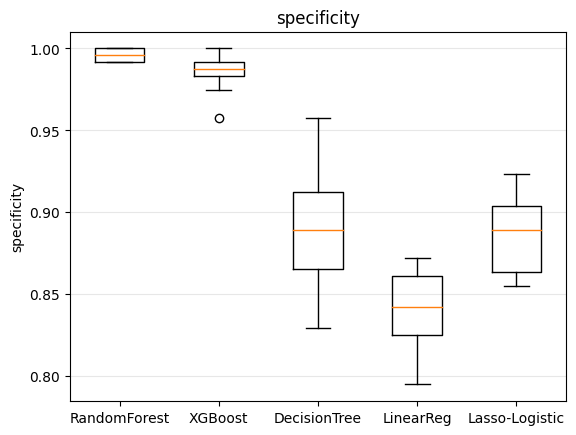

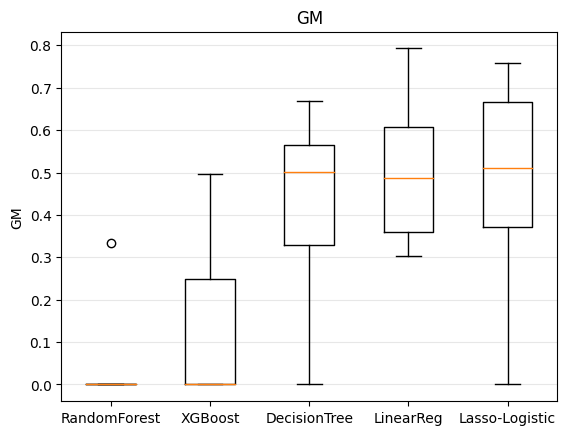

In [58]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

imp = SimpleImputer(strategy='median')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

xgb_pipe = ImbPipeline(steps=[('impute', imp),
                           ('smote', smote),
                           ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

lasso_logit_pipe = ImbPipeline(steps=[('impute', imp),
                                   ('scaler', StandardScaler()),
                                   ('smote', smote),
                                   ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

rfc_pipe = ImbPipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

dt_pipe = ImbPipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', DecisionTreeClassifier(random_state=42))])

linr_pipe = ImbPipeline(steps=[('impute', imp),
                            ('scaler',StandardScaler()),
                            ('smote', smote),
                            ('clf', LinearRegression())])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("LinearReg", linr_pipe), ("Lasso-Logistic", lasso_logit_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()



---
### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, KNN補值
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9314 | 0.0051 |    0.0361   |    0.9949   | 0.1039 |
| **XGBoost**        | 0.9210 | 0.0171 |    0.0472   |    0.9829   | 0.0959 |
| **DecisionTree**   | 0.8357 | 0.1205 |    0.2181   |    0.8795   | 0.4040 |
| **LinearReg**      | 0.8077 | 0.1598 |    0.3514   |    0.8402   | 0.5225 |
| **Lasso-Logistic** | 0.8292 | 0.1333 |    0.3000   |    0.8667   | 0.4733 |


[RandomForest] MEAN acc=0.9314 FAR=0.0051 sens=0.0361 spec=0.9949 GM=0.1039
[XGBoost] MEAN acc=0.9210 FAR=0.0171 sens=0.0472 spec=0.9829 GM=0.0959
[DecisionTree] MEAN acc=0.8357 FAR=0.1205 sens=0.2181 spec=0.8795 GM=0.4040
[LinearReg] MEAN acc=0.8077 FAR=0.1598 sens=0.3514 spec=0.8402 GM=0.5225


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of ite

[Lasso-Logistic] MEAN acc=0.8292 FAR=0.1333 sens=0.3000 spec=0.8667 GM=0.4733


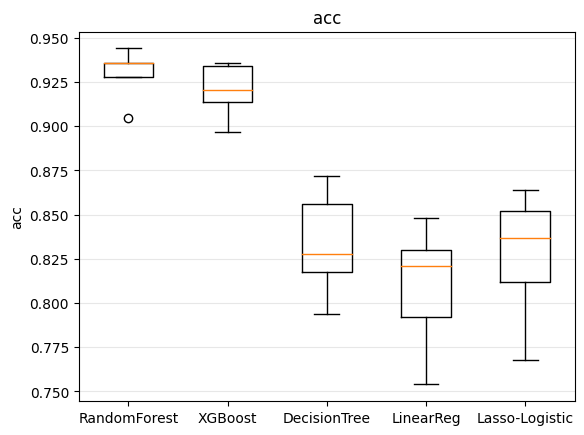

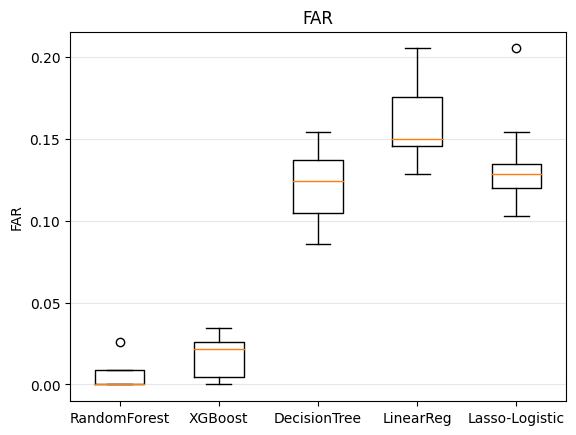

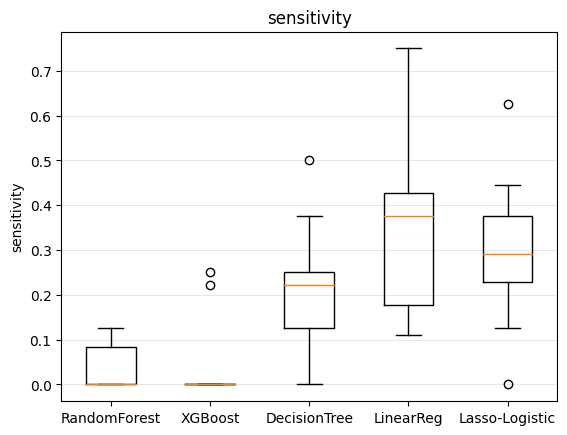

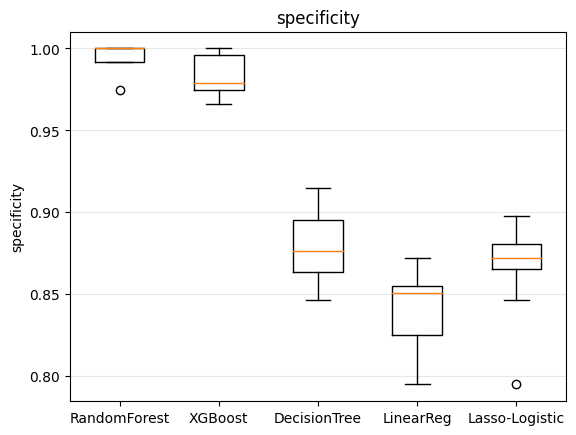

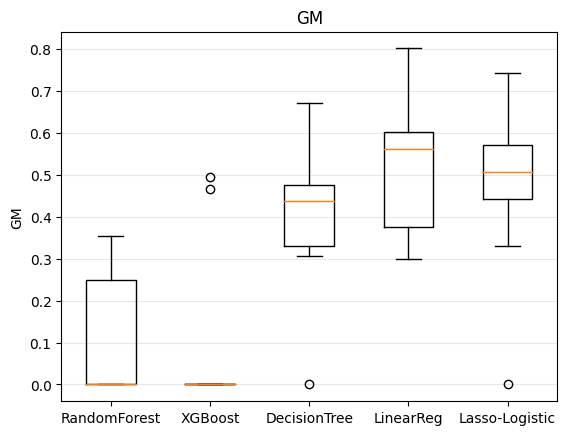

In [62]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被每折覆蓋

from imblearn.pipeline import Pipeline as ImbPipeline

xgb_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

lasso_logit_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

rfc_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

dt_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(random_state=42))])

linr_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', LinearRegression())])

models = [
    ('RandomForest', rfc_pipe),
    ('XGBoost', xgb_pipe),
    ('DecisionTree', dt_pipe),
    ('LinearReg', linr_pipe),
    ('Lasso-Logistic', lasso_logit_pipe)]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)

for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

---
### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, KNN補值, 隨機森林特徵選擇 k=156
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9314 | 0.0051 |    0.0361   |    0.9949   | 0.1039 |
| **XGBoost**        | 0.9210 | 0.0171 |    0.0472   |    0.9829   | 0.0959 |
| **DecisionTree**   | 0.8357 | 0.1205 |    0.2181   |    0.8795   | 0.4040 |
| **LinearReg**      | 0.8069 | 0.1632 |    0.3861   |    0.8368   | 0.5495 |
| **Lasso-Logistic** | 0.8396 | 0.1214 |    0.2903   |    0.8786   | 0.4662 |


Best k (by TEST ACC with SMOTE) = 156


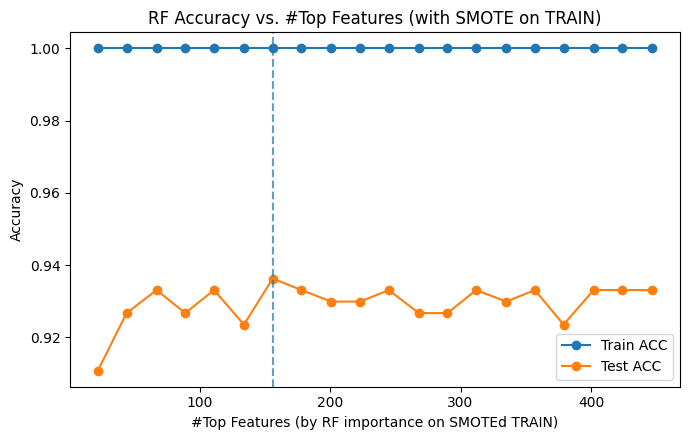

In [64]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

knn = KNNImputer(n_neighbors=10, weights='distance')
X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)

minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

rf_base = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  #

p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs, test_accs = [], []

for k in ks:
    cols_k = X_train_imp.columns[feat_order[:k]]
    minority_n_k = int((y_train == 1).sum())
    k_smote_k = max(1, min(5, minority_n_k - 1))
    smote_k = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote_k, random_state=42)
    X_tr_k, y_tr_k = smote_k.fit_resample(X_train_imp[cols_k], y_train)

    rf_k = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_k.fit(X_tr_k, y_tr_k)

    y_tr_hat = rf_k.predict(X_tr_k)
    y_te_hat = rf_k.predict(X_test_imp[cols_k])

    train_accs.append(accuracy_score(y_tr_k, y_tr_hat))
    test_accs.append(accuracy_score(y_test, y_te_hat))

best_idx = int(np.argmax(test_accs))
best_k = ks[best_idx]
print(f"Best k (by TEST ACC with SMOTE) = {best_k}")

plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs, marker='o', label='Train ACC')
plt.plot(ks, test_accs, marker='o', label='Test ACC')
plt.axvline(best_k, linestyle='--', alpha=0.7)
plt.title('RF Accuracy vs. #Top Features (with SMOTE on TRAIN)')
plt.xlabel('#Top Features (by RF importance on SMOTEd TRAIN)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

[RandomForest] MEAN acc=0.9314 FAR=0.0051 sens=0.0361 spec=0.9949 GM=0.1039
[XGBoost] MEAN acc=0.9210 FAR=0.0171 sens=0.0472 spec=0.9829 GM=0.0959
[DecisionTree] MEAN acc=0.8357 FAR=0.1205 sens=0.2181 spec=0.8795 GM=0.4040
[LinearReg] MEAN acc=0.8069 FAR=0.1632 sens=0.3861 spec=0.8368 GM=0.5495
[Lasso-Logistic] MEAN acc=0.8396 FAR=0.1214 sens=0.2903 spec=0.8786 GM=0.4662


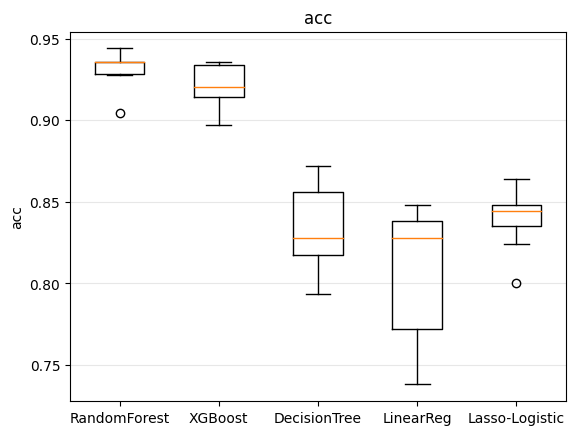

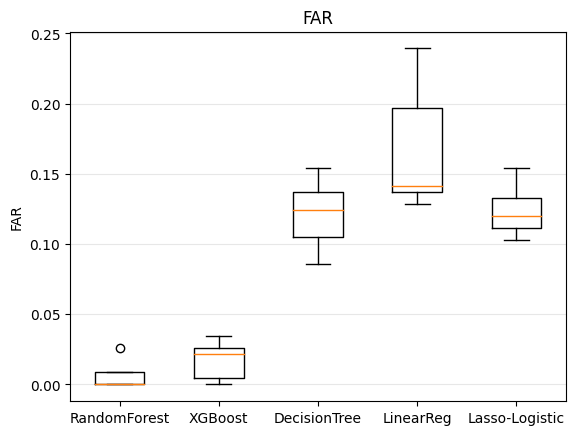

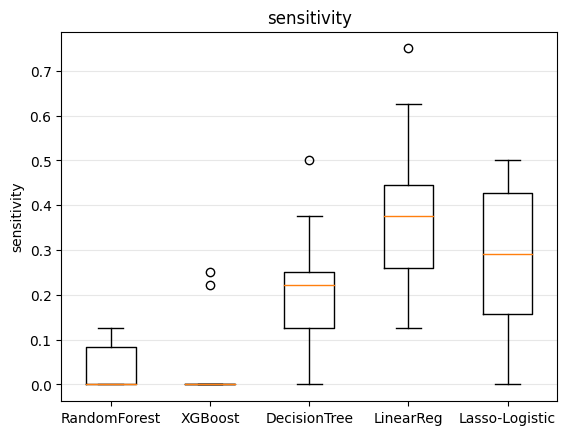

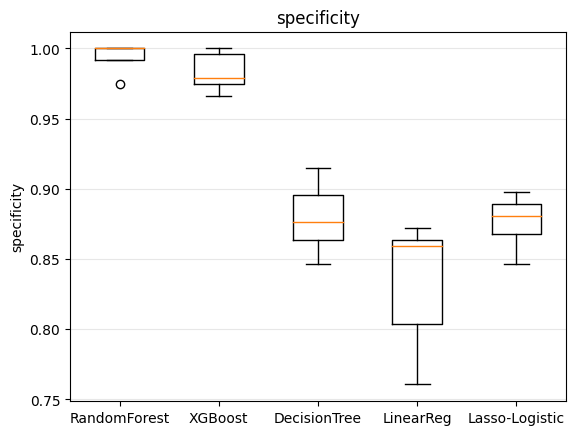

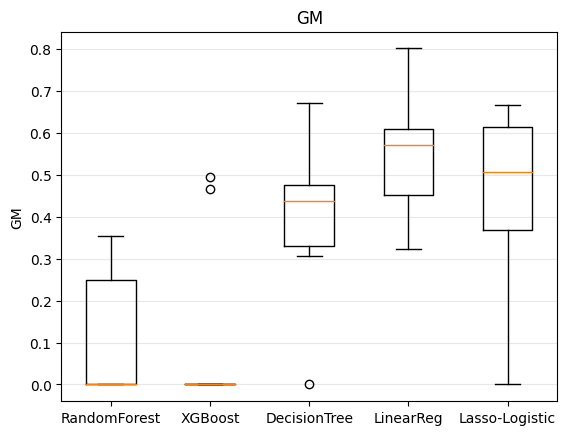

In [67]:
best_k = 156
cols_topk = X_train.columns[feat_order[:best_k]].tolist()

X_train_k = X_train[cols_topk].copy()
X_test_k  = X_test[cols_topk].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')

smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k


xgb_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

dt_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(random_state=42))
])

linr_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())
])

logit_l1_pipe = ImbPipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

rfc_pipe = ImbPipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

models = [
    ('RandomForest', rfc_pipe),
    ("XGBoost", xgb_pipe),
    ("DecisionTree", dt_pipe),
    ("LinearReg", linr_pipe),
    ("Lasso-Logistic", logit_l1_pipe),
]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

---
### 所有機器學習模型的10折結果, 作缺值, 相關性特徵選擇, 中位數補值, 隨機森林特徵選擇 k=108
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9314 | 0.0043 |    0.0222   |    0.9957   | 0.0664 |
| **XGBoost**        | 0.9218 | 0.0188 |    0.0819   |    0.9812   | 0.1947 |
| **DecisionTree**   | 0.8412 | 0.1171 |    0.2528   |    0.8829   | 0.4412 |
| **LinearReg**      | 0.8077 | 0.1590 |    0.3389   |    0.8410   | 0.4866 |
| **Lasso-Logistic** | 0.8420 | 0.1179 |    0.2778   |    0.8821   | 0.4325 |



Best k (by TEST ACC with SMOTE) = 108
Train ACC = 1.0000, Test ACC = 0.9331


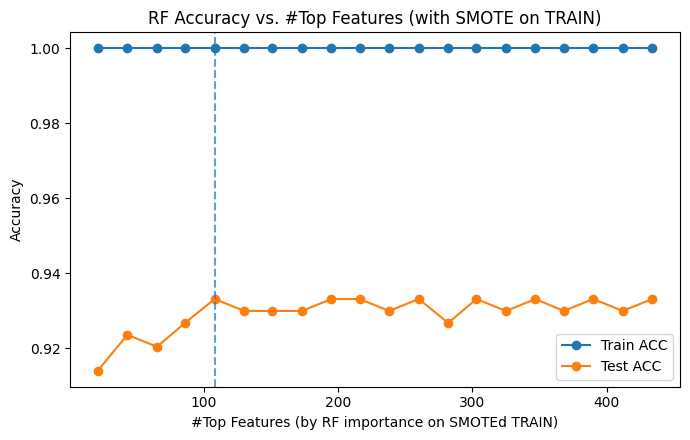

In [73]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

imp = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imp.transform(X_test), columns=X_test.columns, index=X_test.index)

minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1] 

p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs, test_accs = [], []

for k in ks:
    cols_k = X_train_imp.columns[feat_order[:k]]
    minority_n_k = int((y_train == 1).sum())
    k_smote_k = max(1, min(5, minority_n_k - 1))
    smote_k = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote_k, random_state=42)
    X_tr_k, y_tr_k = smote_k.fit_resample(X_train_imp[cols_k], y_train)

    rf_k = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_k.fit(X_tr_k, y_tr_k)

    y_tr_hat = rf_k.predict(X_tr_k)
    y_te_hat = rf_k.predict(X_test_imp[cols_k])

    train_accs.append(accuracy_score(y_tr_k, y_tr_hat))
    test_accs.append(accuracy_score(y_test, y_te_hat))

best_idx = int(np.argmax(test_accs))
best_k = ks[best_idx]
print(f"Best k (by TEST ACC with SMOTE) = {best_k}")
print(f"Train ACC = {train_accs[best_idx]:.4f}, Test ACC = {test_accs[best_idx]:.4f}")

plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs, marker='o', label='Train ACC')
plt.plot(ks, test_accs, marker='o', label='Test ACC')
plt.axvline(best_k, linestyle='--', alpha=0.7)
plt.title('RF Accuracy vs. #Top Features (with SMOTE on TRAIN)')
plt.xlabel('#Top Features (by RF importance on SMOTEd TRAIN)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

[RandomForest] MEAN acc=0.9314 FAR=0.0043 sens=0.0222 spec=0.9957 GM=0.0664
[XGBoost] MEAN acc=0.9218 FAR=0.0188 sens=0.0819 spec=0.9812 GM=0.1947
[DecisionTree] MEAN acc=0.8412 FAR=0.1171 sens=0.2528 spec=0.8829 GM=0.4412
[LinearReg] MEAN acc=0.8077 FAR=0.1590 sens=0.3389 spec=0.8410 GM=0.4866
[Lasso-Logistic] MEAN acc=0.8420 FAR=0.1179 sens=0.2778 spec=0.8821 GM=0.4325


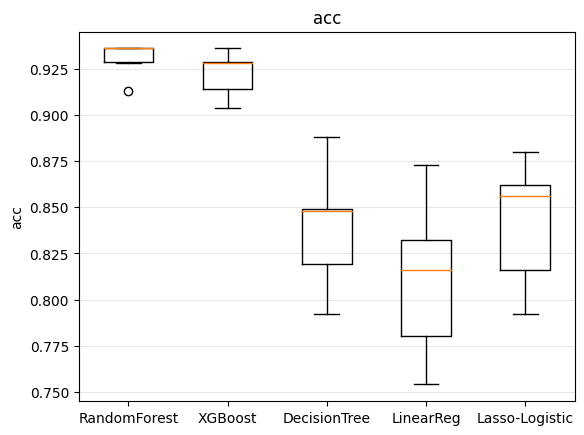

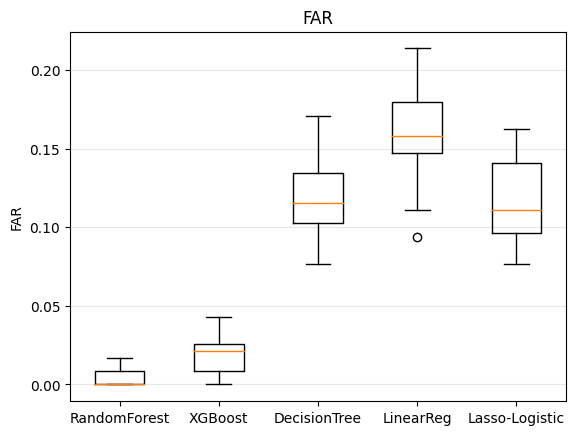

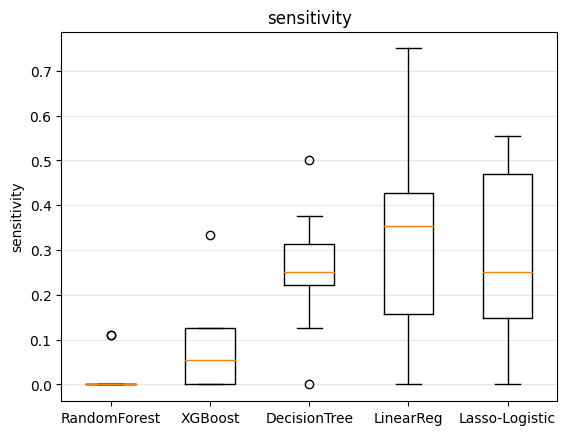

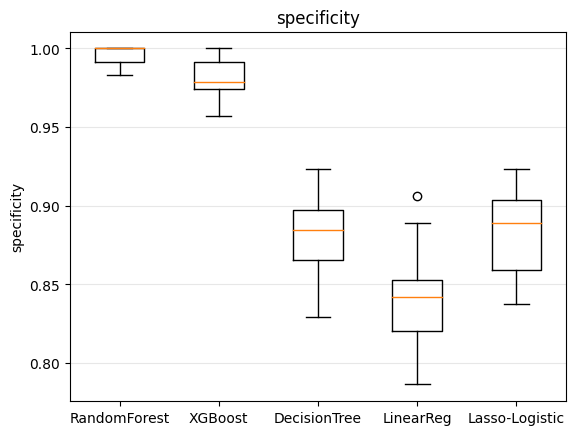

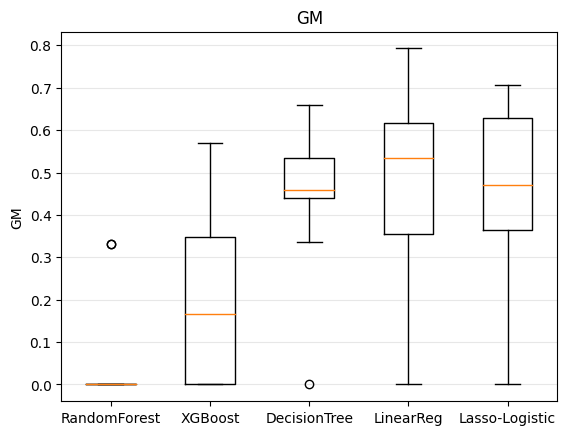

In [52]:
best_k = 108
cols_topk = X_train.columns[feat_order[:best_k]].tolist()

X_train_k = X_train[cols_topk].copy()
X_test_k  = X_test[cols_topk].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}")
    return avg, df

imp = SimpleImputer(strategy='median')

smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k


xgb_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[
    ('impute', imp),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(random_state=42))
])

linr_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())
])

logit_l1_pipe = Pipeline(steps=[
    ('impute', imp),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

rfc_pipe = Pipeline(steps=[('impute', imp),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

models = [
    ('RandomForest', rfc_pipe),
    ("XGBoost", xgb_pipe),
    ("DecisionTree", dt_pipe),
    ("LinearReg", linr_pipe),
    ("Lasso-Logistic", logit_l1_pipe),
]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)

cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖
for metric in METRICS:
    plt.figure()
    data = [cv_df.loc[cv_df['model']==m, metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric}')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

---
### 所有機器學習模型的10折結果, KNN補值, 50次隨機森林投票特徵選取50個 (seed=42)
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9202 | 0.0239 |    0.1333   |    0.9761   | 0.2549 |
| **XGBoost**        | 0.9059 | 0.0402 |    0.1458   |    0.9598   | 0.3283 |
| **DecisionTree**   | 0.8244 | 0.1299 |    0.1806   |    0.8701   | 0.3240 |
| **LinearReg**      | 0.7423 | 0.2402 |    0.4917   |    0.7598   | 0.6023 |
| **Lasso-Logistic** | 0.7527 | 0.2282 |    0.4806   |    0.7718   | 0.6005 |

In [75]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def rf_feature_stability(X: pd.DataFrame, y: pd.Series, k_top: int = 50, n_splits: int = 10, n_repeats: int = 5, knn_k: int = 10):
    feat_names = np.array(X.columns)
    counts = pd.Series(0, index=feat_names, dtype=int)
    imp_sum = pd.Series(0.0, index=feat_names, dtype=float)

    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    total_folds = n_splits * n_repeats

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    for tr_idx, _ in rskf.split(X, y):
        X_tr = X.iloc[tr_idx]
        y_tr = y.iloc[tr_idx]

        imp = KNNImputer(n_neighbors=knn_k, weights='distance')
        X_tr_imp = imp.fit_transform(X_tr)

        rf.fit(X_tr_imp, y_tr)
        importances = pd.Series(rf.feature_importances_, index=feat_names)

        topk = importances.nlargest(k_top).index
        counts[topk] += 1
        imp_sum += importances  # 可用來做平均重要度參考

    stability = counts / total_folds
    imp_mean = imp_sum / total_folds

    out = pd.DataFrame({
        'count_selected': counts,
        'stability': stability,
        'mean_importance': imp_mean
    }).sort_values(['stability','mean_importance'], ascending=False)

    return out, total_folds

out_df, total = rf_feature_stability(X, y, k_top=50, n_splits=10, n_repeats=5, knn_k=10)

RF_KW = dict(random_state=42, n_jobs=-1)

def eval_topk_by_acc(out_df, X, y, k_grid, test_size=0.2, knn_k=10, random_state=42):
    ranked_feats = out_df.index.tolist()
    max_k = min(max(k_grid), len(ranked_feats))

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    rows = []
    for k in sorted(k for k in k_grid if k <= max_k):
        feats = ranked_feats[:k]

        imputer = KNNImputer(n_neighbors=knn_k, weights='distance')
        X_tr_imp = imputer.fit_transform(X_tr[feats])
        X_te_imp = imputer.transform(X_te[feats])

        rf = RandomForestClassifier(**RF_KW)
        rf.fit(X_tr_imp, y_tr)

        y_tr_pred = rf.predict(X_tr_imp)
        y_te_pred = rf.predict(X_te_imp)

        rows.append({
            'k': k,
            'train_acc': accuracy_score(y_tr, y_tr_pred),
            'test_acc':  accuracy_score(y_te, y_te_pred)
        })

    res = pd.DataFrame(rows).sort_values('k')
    best_idx = res['test_acc'].idxmax()
    best_k = int(res.loc[best_idx, 'k'])
    best_feats = ranked_feats[:best_k]
    return res, best_k, best_feats

k_grid = range(10, 201, 10)
res_df, best_k, best_feats = eval_topk_by_acc(out_df, X, y, k_grid, test_size=0.2, knn_k=10)

print(res_df)
print(f"Best k (by TEST ACC) = {best_k}")

      k  train_acc  test_acc
0    10        1.0  0.929936
1    20        1.0  0.936306
2    30        1.0  0.933121
3    40        1.0  0.929936
4    50        1.0  0.939490
5    60        1.0  0.933121
6    70        1.0  0.933121
7    80        1.0  0.933121
8    90        1.0  0.936306
9   100        1.0  0.933121
10  110        1.0  0.929936
11  120        1.0  0.933121
12  130        1.0  0.933121
13  140        1.0  0.933121
14  150        1.0  0.933121
15  160        1.0  0.933121
16  170        1.0  0.933121
17  180        1.0  0.933121
18  190        1.0  0.929936
19  200        1.0  0.933121
Best k (by TEST ACC) = 50


[RandomForest] MEAN acc=0.9202 FAR=0.0239 sens=0.1333 spec=0.9761 GM=0.2549

[XGBoost] MEAN acc=0.9059 FAR=0.0402 sens=0.1458 spec=0.9598 GM=0.3283

[DecisionTree] MEAN acc=0.8244 FAR=0.1299 sens=0.1806 spec=0.8701 GM=0.3240

[LinearReg] MEAN acc=0.7423 FAR=0.2402 sens=0.4917 spec=0.7598 GM=0.6023

[Lasso-Logistic] MEAN acc=0.7527 FAR=0.2282 sens=0.4806 spec=0.7718 GM=0.6005



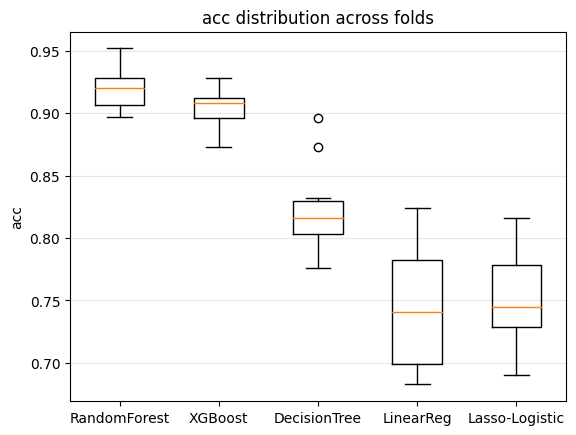

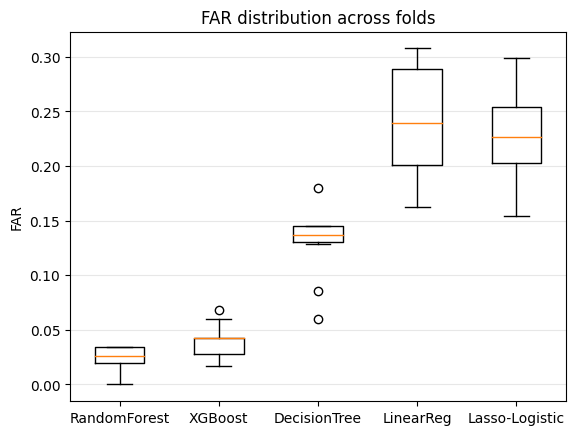

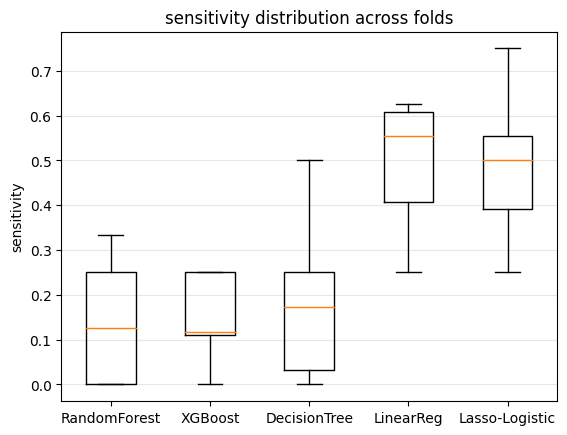

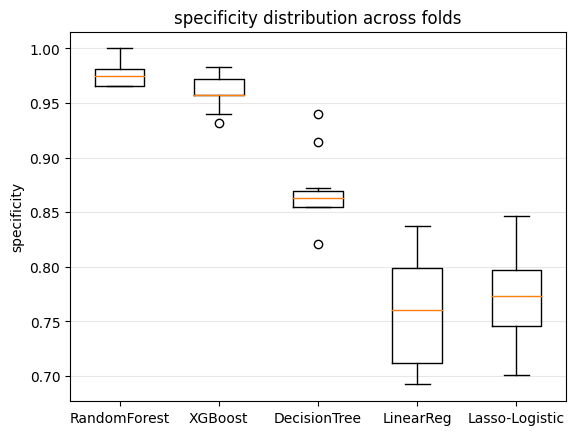

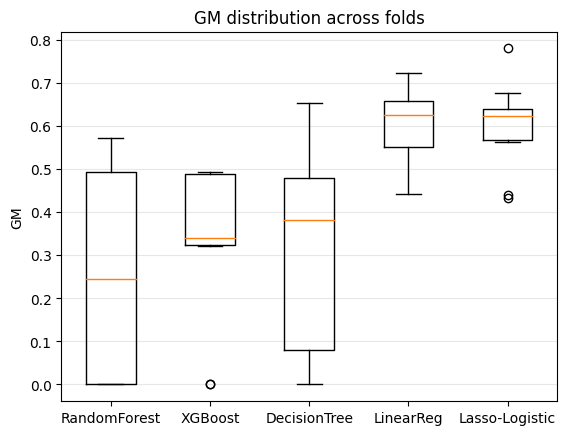

In [77]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

METRICS = ['acc','FAR','sensitivity','specificity','GM']
def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        # 分類器：predict；線回歸：predict後以0.5切
        if model_name == "LinearReg":
            y_hat = (pipe.predict(X_te) >= 0.5).astype(int)
        else:
            y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {k: df[k].mean() for k in METRICS}
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} "
          f"sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg, df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train_k = X_train[best_feats].copy()
X_test_k  = X_test[best_feats].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

xgb_pipe = Pipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', XGBClassifier(random_state=42, n_jobs=-1))])

dt_pipe = Pipeline(steps=[
    ('impute', knn),
    ('smote', smote),
    ('clf', DecisionTreeClassifier(random_state=42))])

linr_pipe = Pipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LinearRegression())])

logit_l1_pipe = Pipeline(steps=[
    ('impute', knn),
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])


rfc_pipe = Pipeline(steps=[('impute', knn),
                          ('smote', smote),
                          ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

models = [('RandomForest', rfc_pipe), 
          ("XGBoost", xgb_pipe), 
          ("DecisionTree", dt_pipe),
          ("LinearReg", linr_pipe),
          ("Lasso-Logistic", logit_l1_pipe),]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_train_k, y_train)
    all_avg[name] = avg
    fold_dfs.append(df)
    
cv_df = pd.concat(fold_dfs, ignore_index=True)  # 欄位：model, fold, acc, FAR, sensitivity, specificity, GM

# 盒鬚圖（快速看離散度）
for metric in METRICS:
    plt.figure()
    data = [cv_df[cv_df['model']==m][metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric} distribution across folds')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()



---
### 所有機器學習模型的10折結果, KNN補值, 50次隨機森林投票特徵選取40個 (seed=611211106)
| Model              |   ACC  |   FAR  | Sensitivity | Specificity |   GM   |
| :----------------- | :----: | :----: | :---------: | :---------: | :----: |
| **RandomForest**   | 0.9114 | 0.0342 |    0.1458   |    0.9658   | 0.3012 |
| **XGBoost**        | 0.8970 | 0.0479 |    0.1222   |    0.9521   | 0.2751 |
| **DecisionTree**   | 0.8156 | 0.1504 |    0.3375   |    0.8496   | 0.5152 |
| **Lasso-Logistic** | 0.7766 | 0.2094 |    0.5778   |    0.7906   | 0.6726 |




In [78]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(611211106)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=611211106)

# 穩定選特徵 只在X_dev上做
k_top = 50
n_splits = 10
n_repeats = 5
knn_k = 10

feat_names = np.array(X_dev.columns)
counts = pd.Series(0, index=feat_names, dtype=int)   # 被選入前 k_top 的次數
imp_sum = pd.Series(0.0, index=feat_names, dtype=float)

rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=611211106)
rf = RandomForestClassifier(random_state=611211106, n_jobs=-1)

for tr_idx, _ in rskf.split(X_dev, y_dev):
    X_tr = X_dev.iloc[tr_idx]
    y_tr = y_dev.iloc[tr_idx]

    imputer = KNNImputer(n_neighbors=knn_k, weights='distance')
    X_tr_imp = imputer.fit_transform(X_tr)

    rf.fit(X_tr_imp, y_tr)
    importances = pd.Series(rf.feature_importances_, index=feat_names)

    topk = importances.nlargest(k_top).index
    counts[topk] += 1
    imp_sum += importances

total_folds = n_splits*n_repeats
stability = counts/total_folds
imp_mean = imp_sum/total_folds

out = pd.DataFrame({'count_selected': counts, 'stability': stability, 'mean_importance': imp_mean}).sort_values(['stability','mean_importance'], ascending=False)

ranked_feats = out.index.tolist()

scorer = make_scorer(roc_auc_score, needs_threshold=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_grid = range(10, 201, 10)
rows = []

for k in k_grid:
    feats = ranked_feats[:k]
    X_sub = X_dev[feats]

    pipe = Pipeline(steps=[('imp', KNNImputer(n_neighbors=10, weights='distance')), 
                           ('rf', RandomForestClassifier(random_state=611211106, n_jobs=-1))])

    cv_scores = cross_val_score(pipe, X_sub, y_dev, cv=skf, scoring=scorer, n_jobs=-1)
    rows.append({'k': k, 'cv_auc_mean': float(np.mean(cv_scores)),
                 'cv_auc_std': float(np.std(cv_scores))})

cv_table = pd.DataFrame(rows).sort_values('k')
best_k = int(cv_table.loc[cv_table['cv_auc_mean'].idxmax(), 'k'])
best_feats = ranked_feats[:best_k]
print(cv_table)
print(f"Best k (by CV ROC-AUC on train_dev) = {best_k}")

# 鎖定最佳k後，在 train_dev 重訓，最後到 test 做一次性評估
final_pipe = Pipeline(steps=[('imp', KNNImputer(n_neighbors=10, weights='distance')),
                             ('rf', RandomForestClassifier(random_state=611211106, n_jobs=-1))])

# 重訓在整個 train_dev 上
X_dev_k  = X_dev[best_feats]
X_test_k = X_test[best_feats]
final_pipe.fit(X_dev_k, y_dev)

# 一次性評估
y_pred = final_pipe.predict(X_test_k)
test_m = compute_metrics(y_test.values, y_pred)
print(test_m)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


      k  cv_auc_mean  cv_auc_std
0    10     0.758572    0.075388
1    20     0.800605    0.053264
2    30     0.787187    0.061335
3    40     0.824587    0.057272
4    50     0.815693    0.054855
5    60     0.820701    0.066393
6    70     0.818164    0.064631
7    80     0.805827    0.067873
8    90     0.796734    0.062104
9   100     0.791715    0.069766
10  110     0.792292    0.037609
11  120     0.793931    0.062116
12  130     0.789574    0.060334
13  140     0.786268    0.060985
14  150     0.792498    0.063244
15  160     0.769899    0.035140
16  170     0.798551    0.061421
17  180     0.782769    0.046428
18  190     0.773795    0.045640
19  200     0.773278    0.059016
Best k (by CV ROC-AUC on train_dev) = 40
{'cm': array([[292,   1],
       [ 21,   0]], dtype=int64), 'acc': 0.9299363057324841, 'FAR': 0.0034129692832764505, 'sensitivity': 0.0, 'specificity': 0.9965870307167235, 'GM': 0.0}


[RandomForest] MEAN acc=0.9114 FAR=0.0342 sens=0.1458 spec=0.9658 GM=0.3012

[XGBoost] MEAN acc=0.8970 FAR=0.0479 sens=0.1222 spec=0.9521 GM=0.2751

[DecisionTree] MEAN acc=0.8156 FAR=0.1504 sens=0.3375 spec=0.8496 GM=0.5152

[Lasso-Logistic] MEAN acc=0.7766 FAR=0.2094 sens=0.5778 spec=0.7906 GM=0.6726



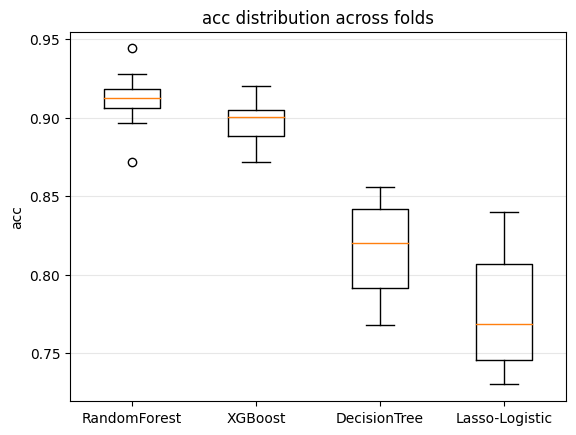

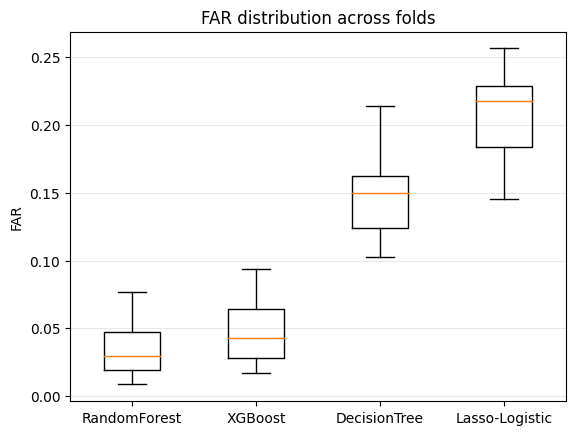

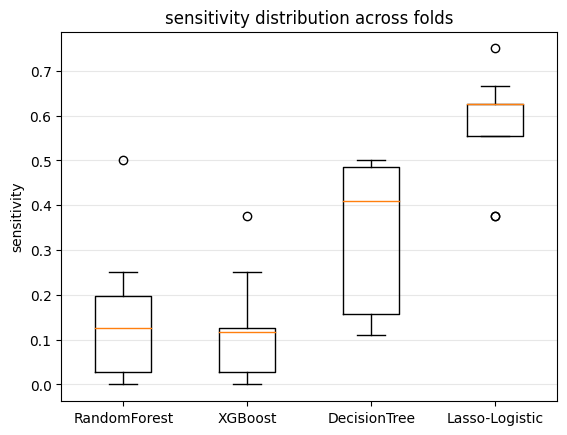

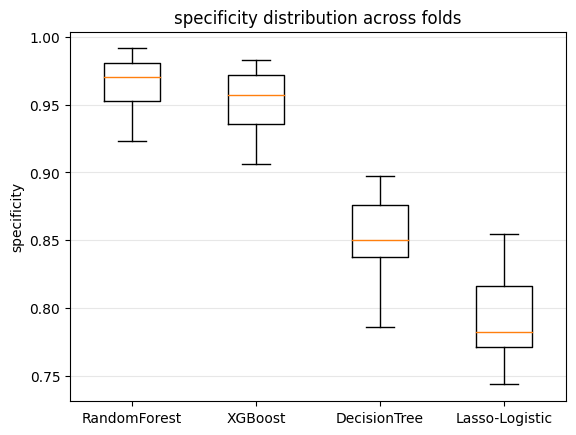

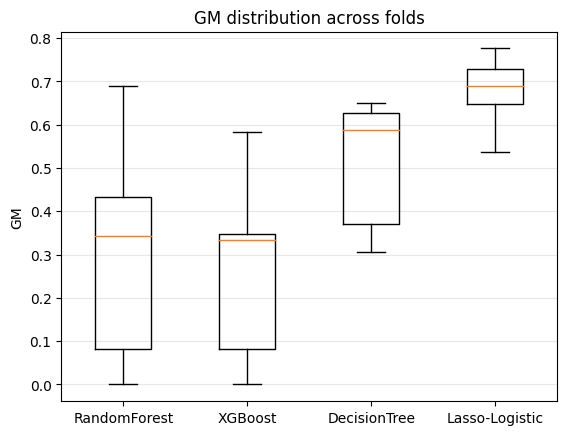

In [79]:
best_feats = ranked_feats[:best_k]

X_dev_k  = X_dev[best_feats].copy()
X_test_k = X_test[best_feats].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

METRICS = ['acc','FAR','sensitivity','specificity','GM']

def run_cv(model_name, pipe, skf, X_train, y_train):
    fold_metrics = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        pipe.fit(X_tr, y_tr)
        y_tr_hat = pipe.predict(X_tr)
        train_acc = accuracy_score(y_tr, y_tr_hat)
        y_hat = pipe.predict(X_te)
        m = compute_metrics(y_te.values, y_hat)
        fold_metrics.append({'model':model_name,'fold':fold, 'train_acc':train_acc, 'test_acc':m['acc'], **{k:m[k] for k in METRICS}})
    df = pd.DataFrame(fold_metrics)
    avg = {'train_acc':df['train_acc'].mean(), 'test_acc':df['test_acc'].mean(), **{k:df[k].mean() for k in METRICS}}
    gap = avg['train_acc']-avg['test_acc']
    print(f"[{model_name}] MEAN acc={avg['acc']:.4f} FAR={avg['FAR']:.4f} sens={avg['sensitivity']:.4f} spec={avg['specificity']:.4f} GM={avg['GM']:.4f}\n")
    return avg, df

knn = KNNImputer(n_neighbors=10, weights='distance')
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=611211106)  # 會被 run_cv 動態覆蓋 k
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=611211106)

from imblearn.pipeline import Pipeline

xgb_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', XGBClassifier(random_state=611211106, n_jobs=-1))])

dt_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', DecisionTreeClassifier(random_state=611211106))])

logit_l1_pipe = Pipeline(steps=[('impute', knn), ('scaler', StandardScaler()), ('smote', smote), ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=611211106))])

rfc_pipe = Pipeline(steps=[('impute', knn), ('smote', smote), ('clf', RandomForestClassifier(random_state=611211106, n_jobs=-1))])

models = [('RandomForest', rfc_pipe), ("XGBoost", xgb_pipe), ("DecisionTree", dt_pipe), ("Lasso-Logistic", logit_l1_pipe),]

all_avg, fold_dfs = {}, []
for name, pipe in models:
    avg, df = run_cv(name, pipe, skf, X_dev_k, y_dev)
    all_avg[name] = avg
    fold_dfs.append(df)
    
cv_df = pd.concat(fold_dfs, ignore_index=True)

# 盒鬚圖（快速看離散度）
for metric in METRICS:
    plt.figure()
    data = [cv_df[cv_df['model']==m][metric].values for m,_ in models]
    labels = [m for m,_ in models]
    plt.boxplot(data, labels=labels, showfliers=True)
    plt.ylabel(metric); plt.title(f'{metric} distribution across folds')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()


---


### 多元迴歸係數排序特徵, 迭代k找最佳test_acc取前k=21的features
| 模型             | Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| DecisionTree   |        0.8312 | 0.1297 |      0.2857 |      0.8703 | 0.4987 |


In [ ]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_tr_imp = imputer.fit_transform(X_train)
X_te_imp = imputer.transform(X_test)

feature_names = X_train.columns.to_list()
p = X_tr_imp.shape[1]

t_vals = []
for j in range(p):
    Xi = sm.add_constant(X_tr_imp[:, j])         # y ~ 1 + x_j
    try:
        fit = sm.OLS(y_train.values, Xi).fit()
        t_vals.append(fit.tvalues[1])            # slope 的 t 值
    except Exception:
        t_vals.append(0.0)                       # 退避：發生數值問題時設 0

abs_t = np.abs(np.array(t_vals))
rank_idx = np.argsort(-abs_t)                    # 由大到小
ranked_features = [feature_names[i] for i in rank_idx]

smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)

best = {"k": None, "train_acc": -1, "test_acc": -1}
records = []

for k in range(1, p+1):
    sel = rank_idx[:k]
    Xtr_k, Xte_k = X_tr_imp[:, sel], X_te_imp[:, sel]

    Xtr_bal, ytr_bal = smote.fit_resample(Xtr_k, y_train)

    clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
    clf.fit(Xtr_bal, ytr_bal)

    y_tr_hat = clf.predict(Xtr_k)
    y_te_hat = clf.predict(Xte_k)

    tr_acc = accuracy_score(y_train, y_tr_hat)
    te_acc = accuracy_score(y_test,  y_te_hat)
    records.append((k, tr_acc, te_acc))

    if (te_acc > best["test_acc"]) or \
       (np.isclose(te_acc, best["test_acc"]) and tr_acc > best["train_acc"]) or \
       (np.isclose(te_acc, best["test_acc"]) and np.isclose(tr_acc, best["train_acc"]) and (best["k"] is None or k < best["k"])):
        best.update({"k": k, "train_acc": tr_acc, "test_acc": te_acc})

print(f"Best k = {best['k']} | train_acc = {best['train_acc']:.4f}, test_acc = {best['test_acc']:.4f}")
best_features = [feature_names[i] for i in rank_idx[:best["k"]]]

sel = rank_idx[:best["k"]]
Xtr_k, Xte_k = X_tr_imp[:, sel], X_te_imp[:, sel]
Xtr_bal, ytr_bal = smote.fit_resample(Xtr_k, y_train)

final_clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
final_clf.fit(Xtr_bal, ytr_bal)
y_te_hat = final_clf.predict(Xte_k)

res = compute_metrics(y_test.values, y_te_hat)
print(f"ACC={res['acc']:.4f} | FAR={res['FAR']:.4f} | sens={res['sensitivity']:.4f} | spec={res['specificity']:.4f} | GM={res['GM']:.4f}")
print(res['cm'])

Best k = 21 | train_acc = 0.9010, test_acc = 0.8312
Selected features (top-k): ['x104', 'x511', 'x60', 'x349', 'x130', 'x432', 'x65', 'x22', 'x126', 'x431', 'x435', 'x317', 'x436', 'x437', 'x29', 'x123', 'x352', 'x125', 'x214', 'x181'] ...
ACC=0.8312 | FAR=0.1297 | sens=0.2857 | spec=0.8703 | GM=0.4987
[[255  38]
 [ 15   6]]


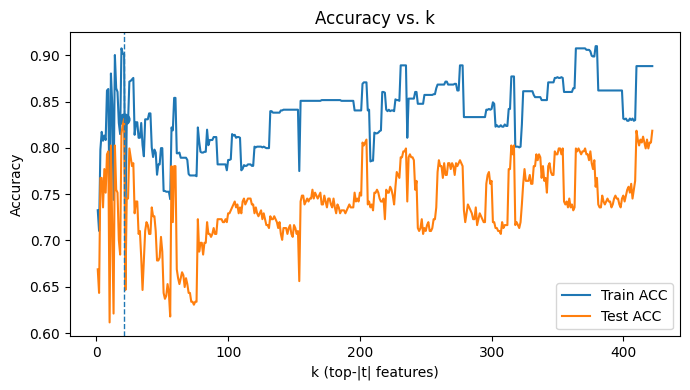

In [26]:
# 將每次 k 的結果轉成表格
rec_df = pd.DataFrame(records, columns=["k", "train_acc", "test_acc"])

# 取得最佳 k 的 test_acc 供標註
best_k = best["k"]
best_test = rec_df.loc[rec_df["k"] == best_k, "test_acc"].values[0]

plt.figure(figsize=(7,4))
plt.plot(rec_df["k"], rec_df["train_acc"], label="Train ACC")
plt.plot(rec_df["k"], rec_df["test_acc"], label="Test ACC")
plt.axvline(best_k, linestyle="--", linewidth=1)
plt.scatter([best_k], [best_test], s=60)

plt.xlabel("k (top-|t| features)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. k")
plt.legend()
plt.tight_layout()
plt.show()

---
---

### 作缺值, 相關性特徵選擇, KNN補值, 隨機森林特徵排序, 迭代k找決策樹最佳test_acc取前k=178的features, 
| 模型             | Accuracy |    FAR | Sensitivity | Specificity |     GM |
| -------------- | ------------: | -----: | ----------: | ----------: | -----: |
| DecisionTree   |        0.8376 | 0.1160 |      0.1905 |      0.8840 | 0.4103 |


[DT] Best k by TEST ACC = 178
[DT] Train ACC = 0.9114, Test ACC = 0.8376


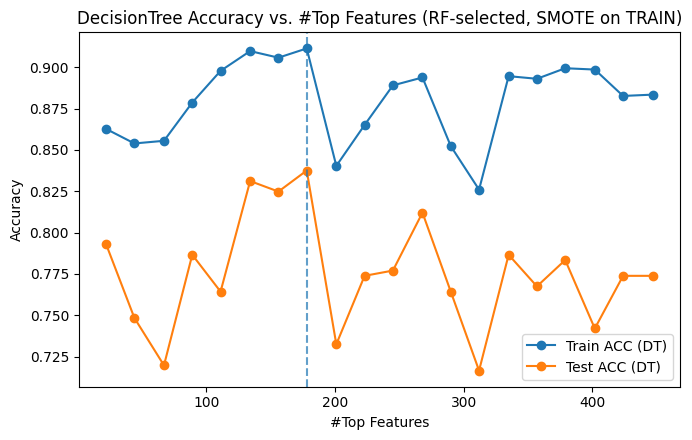

[DT-TEST @ k=178] acc=0.8376 FAR=0.1160 sens=0.1905 spec=0.8840 GM=0.4103
[[259  34]
 [ 17   4]]


In [74]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
seed = 42 
np.random.seed(seed)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


knn = KNNImputer(n_neighbors=10, weights='distance')
smote_base = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=42)  # 迴圈內會被覆蓋
dt_pipe_tpl = imbpipeline.Pipeline(steps=[
    ('impute', knn),
    ('smote', smote_base),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))])

X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)


def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# ── 先在「訓練集」做一次 SMOTE，用於計算特徵重要度的排序 ──
minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=42)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

# ── 3) 先用全特徵的 RF 在「訓練集」上估重要度並排序 ──
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  # 重要度由大到小

p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs_dt, test_accs_dt = [], []

for k in ks:
    cols_k = X_train.columns[feat_order[:k]]

    minority_n = int((y_train == 1).sum())
    k_sm = max(1, min(5, minority_n - 1))

    pipe_k = clone(dt_pipe_tpl)
    pipe_k.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=42))

    pipe_k.fit(X_train[cols_k], y_train)

    y_tr_hat = pipe_k.predict(X_train[cols_k])
    y_te_hat = pipe_k.predict(X_test[cols_k])

    train_accs_dt.append(accuracy_score(y_train, y_tr_hat))
    test_accs_dt.append(accuracy_score(y_test, y_te_hat))

best_idx = int(np.argmax(test_accs_dt))
best_k_dt = ks[best_idx]
print(f"[DT] Best k by TEST ACC = {best_k_dt}")
print(f"[DT] Train ACC = {train_accs_dt[best_idx]:.4f}, Test ACC = {test_accs_dt[best_idx]:.4f}")

plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs_dt, marker='o', label='Train ACC (DT)')
plt.plot(ks, test_accs_dt, marker='o', label='Test ACC (DT)')
plt.axvline(best_k_dt, linestyle='--', alpha=0.7)
plt.title('DecisionTree Accuracy vs. #Top Features (RF-selected, SMOTE on TRAIN)')
plt.xlabel('#Top Features')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

cols_best = X_train.columns[feat_order[:best_k_dt]]
best_pipe_dt = clone(dt_pipe_tpl)
best_pipe_dt.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=42))
best_pipe_dt.fit(X_train[cols_best], y_train)
y_te_hat_best = best_pipe_dt.predict(X_test[cols_best])

try:
    m = compute_metrics(y_test.values, y_te_hat_best)
    print(f"[DT-TEST @ k={best_k_dt}] acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
          f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    print(f'{m['cm']}')
except NameError:
    print(f"[DT-TEST @ k={best_k_dt}] ACC={accuracy_score(y_test, y_te_hat_best):.4f}")

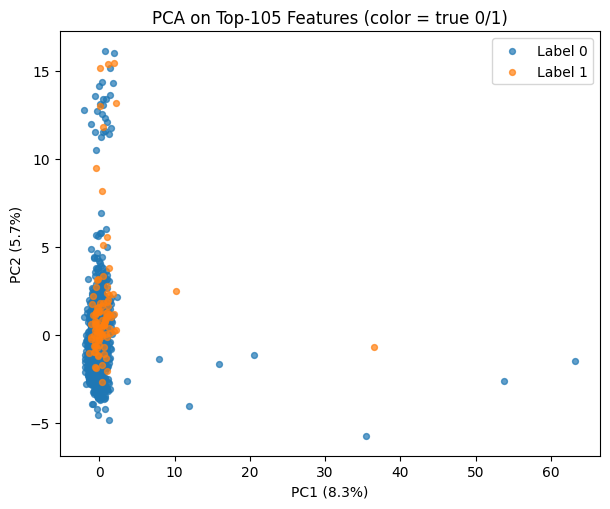

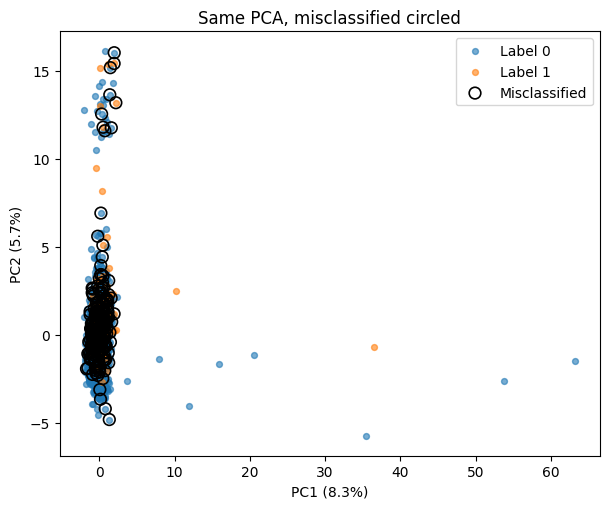

In [5]:
# 1) 準備資料：用已經KNN補好的資料取同一組最佳特徵
Xtr_k = X_train_imp[cols_best].copy()
Xte_k = X_test_imp[cols_best].copy()
ytr   = y_train.copy()
yte   = y_test.copy()

# 2) 標準化與PCA：僅在訓練集fit，測試集transform（避免洩漏）
scaler = StandardScaler().fit(Xtr_k)
Xtr_std = scaler.transform(Xtr_k)
Xte_std = scaler.transform(Xte_k)

pca = PCA(n_components=2, random_state=42).fit(Xtr_std)
Ztr = pca.transform(Xtr_std)
Zte = pca.transform(Xte_std)

# 3) 合併便於作圖
Z_all = np.vstack([Ztr, Zte])
y_all = np.concatenate([ytr.values, yte.values])
is_test = np.concatenate([np.zeros(len(ytr), dtype=bool), np.ones(len(yte), dtype=bool)])

# 4) 取得訓練/測試的預測，之後用來標示錯分點（可視化用）
y_tr_hat_best = best_pipe_dt.predict(X_train[cols_best])  # pipeline 會自己做補值/SMOTE只在fit時
y_te_hat_best = best_pipe_dt.predict(X_test[cols_best])

y_hat_all = np.concatenate([y_tr_hat_best, y_te_hat_best])
mis_idx = (y_hat_all != y_all)

# 5) 作圖：用原始0/1上色；第二張圖圈出錯分
plt.figure(figsize=(6.2,5.2))
for lab in [0,1]:
    idx = (y_all == lab)
    plt.scatter(Z_all[idx,0], Z_all[idx,1], s=18, alpha=0.7, label=f'Label {lab}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'PCA on Top-{len(cols_best)} Features (color = true 0/1)')
plt.legend()
plt.tight_layout()
plt.show()

# 圈出錯分點（空心圈）
plt.figure(figsize=(6.2,5.2))
for lab in [0,1]:
    idx = (y_all == lab)
    plt.scatter(Z_all[idx,0], Z_all[idx,1], s=18, alpha=0.6, label=f'Label {lab}')
# 錯分以空心圈突出
plt.scatter(Z_all[mis_idx,0], Z_all[mis_idx,1], s=70, facecolors='none', edgecolors='k', linewidths=1.2, label='Misclassified')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Same PCA, misclassified circled')
plt.legend()
plt.tight_layout()
plt.show()

### SEED=611211106

[DT] Best k by TEST ACC = 22
[DT] Train ACC = 0.9098, Test ACC = 0.8376


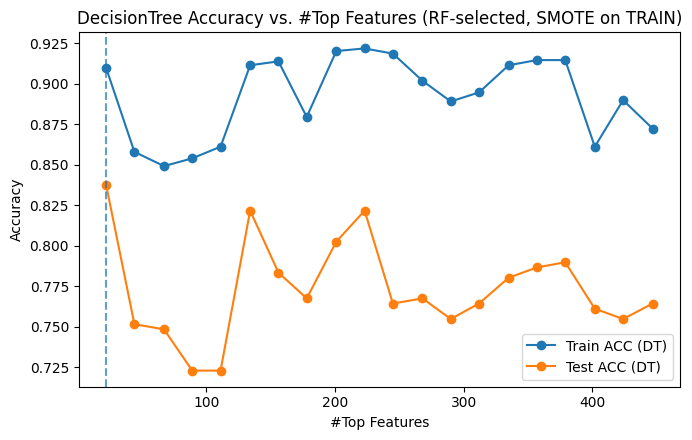

[DT-TEST @ k=22] acc=0.8376 FAR=0.1092 sens=0.0952 spec=0.8908 GM=0.2913
[[261  32]
 [ 19   2]]


In [72]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
seed = 611211106
np.random.seed(seed)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)


knn = KNNImputer(n_neighbors=10, weights='distance')
smote_base = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=seed)  # 迴圈內會被覆蓋
dt_pipe_tpl = imbpipeline.Pipeline(steps=[
    ('impute', knn),
    ('smote', smote_base),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=seed))])

X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)


def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# ── 先在「訓練集」做一次 SMOTE，用於計算特徵重要度的排序 ──
minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=seed)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

# ── 3) 先用全特徵的 RF 在「訓練集」上估重要度並排序 ──
rf_base = RandomForestClassifier(random_state=seed, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  # 重要度由大到小

p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs_dt, test_accs_dt = [], []

for k in ks:
    cols_k = X_train.columns[feat_order[:k]]

    minority_n = int((y_train == 1).sum())
    k_sm = max(1, min(5, minority_n - 1))

    pipe_k = clone(dt_pipe_tpl)
    pipe_k.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=seed))

    pipe_k.fit(X_train[cols_k], y_train)

    y_tr_hat = pipe_k.predict(X_train[cols_k])
    y_te_hat = pipe_k.predict(X_test[cols_k])

    train_accs_dt.append(accuracy_score(y_train, y_tr_hat))
    test_accs_dt.append(accuracy_score(y_test, y_te_hat))

best_idx = int(np.argmax(test_accs_dt))
best_k_dt = ks[best_idx]
print(f"[DT] Best k by TEST ACC = {best_k_dt}")
print(f"[DT] Train ACC = {train_accs_dt[best_idx]:.4f}, Test ACC = {test_accs_dt[best_idx]:.4f}")

plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs_dt, marker='o', label='Train ACC (DT)')
plt.plot(ks, test_accs_dt, marker='o', label='Test ACC (DT)')
plt.axvline(best_k_dt, linestyle='--', alpha=0.7)
plt.title('DecisionTree Accuracy vs. #Top Features (RF-selected, SMOTE on TRAIN)')
plt.xlabel('#Top Features')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

cols_best = X_train.columns[feat_order[:best_k_dt]]
best_pipe_dt = clone(dt_pipe_tpl)
best_pipe_dt.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=seed))
best_pipe_dt.fit(X_train[cols_best], y_train)
y_te_hat_best = best_pipe_dt.predict(X_test[cols_best])

try:
    m = compute_metrics(y_test.values, y_te_hat_best)
    print(f"[DT-TEST @ k={best_k_dt}] acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
          f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    print(f'{m['cm']}')
except NameError:
    print(f"[DT-TEST @ k={best_k_dt}] ACC={accuracy_score(y_test, y_te_hat_best):.4f}")

---
---

[DT] Best k by TEST ACC = 22
[DT] Train ACC = 0.8947, Test ACC = 0.8089


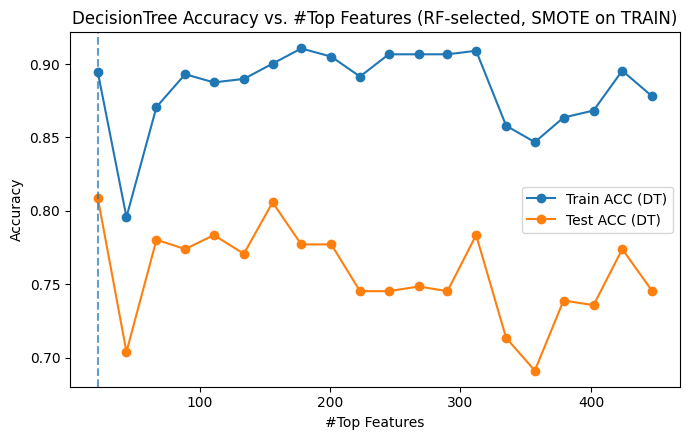

[DT-TEST @ k=22] acc=0.8089 FAR=0.1433 sens=0.1429 spec=0.8567 GM=0.3498
[[251  42]
 [ 18   3]]


In [70]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
seed = 611211106
np.random.seed(seed)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

imp = SimpleImputer(strategy='median')
smote_base = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=seed)  # 迴圈內會被覆蓋
dt_pipe_tpl = imbpipeline.Pipeline(steps=[
    ('impute', imp),
    ('smote', smote_base),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=seed))])

knn = KNNImputer(n_neighbors=10, weights='distance')
X_train_imp = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(knn.transform(X_test), columns=X_test.columns, index=X_test.index)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# ── 先在「訓練集」做一次 SMOTE，用於計算特徵重要度的排序 ──
minority_n = int((y_train == 1).sum())
k_smote = max(1, min(5, minority_n - 1))  # 動態 k
smote = SMOTE(sampling_strategy=1.0, k_neighbors=k_smote, random_state=seed)
Xb_imp, yb = smote.fit_resample(X_train_imp, y_train)

# ── 3) 先用全特徵的 RF 在「訓練集」上估重要度並排序 ──
rf_base = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
rf_base.fit(Xb_imp, yb)
importances = rf_base.feature_importances_
feat_order = np.argsort(importances)[::-1]  # 重要度由大到小

p = X_train_imp.shape[1]
ks = sorted(set([max(5, int(p*ratio)) for ratio in np.linspace(0.05, 1.0, 20)]))
ks = [k for k in ks if k <= p]

train_accs_dt, test_accs_dt = [], []

for k in ks:  
    cols_k = X_train.columns[feat_order[:k]]
    minority_n = int((y_train == 1).sum())
    k_sm = max(1, min(5, minority_n - 1))

    pipe_k = clone(dt_pipe_tpl)
    pipe_k.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=seed))

    pipe_k.fit(X_train[cols_k], y_train)

    y_tr_hat = pipe_k.predict(X_train[cols_k])
    y_te_hat = pipe_k.predict(X_test[cols_k])

    train_accs_dt.append(accuracy_score(y_train, y_tr_hat))
    test_accs_dt.append(accuracy_score(y_test, y_te_hat))

best_idx = int(np.argmax(test_accs_dt))
best_k_dt = ks[best_idx]
print(f"[DT] Best k by TEST ACC = {best_k_dt}")
print(f"[DT] Train ACC = {train_accs_dt[best_idx]:.4f}, Test ACC = {test_accs_dt[best_idx]:.4f}")

plt.figure(figsize=(7,4.5))
plt.plot(ks, train_accs_dt, marker='o', label='Train ACC (DT)')
plt.plot(ks, test_accs_dt, marker='o', label='Test ACC (DT)')
plt.axvline(best_k_dt, linestyle='--', alpha=0.7)
plt.title('DecisionTree Accuracy vs. #Top Features (RF-selected, SMOTE on TRAIN)')
plt.xlabel('#Top Features')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

cols_best = X_train.columns[feat_order[:best_k_dt]]
best_pipe_dt = clone(dt_pipe_tpl)
best_pipe_dt.set_params(smote=SMOTE(sampling_strategy=1.0, k_neighbors=k_sm, random_state=seed))
best_pipe_dt.fit(X_train[cols_best], y_train)
y_te_hat_best = best_pipe_dt.predict(X_test[cols_best])

try:
    m = compute_metrics(y_test.values, y_te_hat_best)
    print(f"[DT-TEST @ k={best_k_dt}] acc={m['acc']:.4f} FAR={m['FAR']:.4f} "
          f"sens={m['sensitivity']:.4f} spec={m['specificity']:.4f} GM={m['GM']:.4f}")
    print(f'{m['cm']}')
except NameError:
    print(f"[DT-TEST @ k={best_k_dt}] ACC={accuracy_score(y_test, y_te_hat_best):.4f}")

---
---